### Tarea #1 Gema Guerra Valdez (1819110)

#### Requisitos

- Realizar un análisis estadístico sobre algún origen de datos textual (libros, publicaciones en redes sociales, entradas de blog, discursos políticos...) sobre dos o más fuentes de uno o más autores.

- Analizar estadística descriptiva básica, frecuencias, distribuciones de palabras, n-gramas, uso de signos de puntuación, emojis...

- Comparar las diversas fuentes y aventurar conclusiones a partir de los hallazgos en un reporte científico (de preferencia hecho en Latex; si no en Markdown como `readme.md` del repositorio).

- Sube a tu repositorio el código utilizado en tu tarea y el reporte en PDF (y TEX si aplica) en una carpeta claramente identificada.

### Edgar Allan Poe

**The Raven**

(1845, Poema, Luto, Angustia, Soledad)

vs.

**The Masque of the Red Death**

(1842, Cuento, Terror, Ficción gótica)

In [1]:
import collections
import re
import string
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from nltk.util import ngrams

In [17]:
nltk.download("stopwords")
nltk.download("punkt_tab")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [19]:
def load_text(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        return f.read()

In [18]:
def basic_descriptive_stats(text):

    tokens = nltk.word_tokenize(text.lower())
    words = [t for t in tokens if t.isalnum()]
    sentences = nltk.sent_tokenize(text)

    total_chars = len(text)
    total_words = len(words)
    unique_words = len(set(words))
    total_sentences = len(sentences)

    # Riqueza léxica (Type-Token Ratio)
    lexical_diversity = unique_words / total_words if total_words > 0 else 0
    avg_word_len = np.mean([len(w) for w in words]) if words else 0
    avg_sent_len = total_words / total_sentences if total_sentences > 0 else 0

    stats = {
        "Total Caracteres": total_chars,
        "Total Palabras": total_words,
        "Vocabulario Único": unique_words,
        "Total Oraciones": total_sentences,
        "Riqueza Léxica (TTR)": round(lexical_diversity, 4),
        "Longitud Promedio Palabra": round(avg_word_len, 2),
        "Longitud Promedio Oración": round(avg_sent_len, 2),
    }
    return stats, words, tokens

In [20]:
# Cuenta la frecuencia de signos de puntuación y detecta caracteres especiales/emojis.

def analyze_punctuation_and_emojis(text):
    # Contar signos de puntuación estándar
    punc_counts = {char: text.count(char) for char in string.punctuation}

    # Filtrar solo los que aparecen
    punc_counts = {k: v for k, v in punc_counts.items() if v > 0}

    # Regex simple para identificar Emojis (Rangos Unicode comunes)
    emoji_pattern = re.compile(r"[\U00010000-\U0010ffff]", flags=re.UNICODE)
    emojis_found = emoji_pattern.findall(text)
    emoji_counts = dict(collections.Counter(emojis_found))

    return punc_counts, emoji_counts

In [21]:
# Genera n-gramas limpiando stop words en ingles.
def get_ngrams_and_freq(words, n=2, top_k=10):

    stop_words = set(stopwords.words("english"))
    filtered_words = [w for w in words if w not in stop_words]

    n_gram_list = list(ngrams(filtered_words, n))
    freq_dist = collections.Counter(n_gram_list)

    return freq_dist.most_common(top_k)

In [22]:
if __name__ == "__main__":
    # Definimos las rutas exactas de tus archivos en Colab
    ruta_masque = "/content/The Masque of the Red Death.txt"
    ruta_raven = "/content/The Raven.txt"  # Ajusta si tu archivo se llama 'The Raven.txt'

    try:
        # Intentar cargar los textos
        masque = load_text(ruta_masque)
        raven = load_text(ruta_raven)

        # 1. Estadísticas Descriptivas
        stats1, words1, tokens1 = basic_descriptive_stats(masque)
        stats2, words2, tokens2 = basic_descriptive_stats(raven)

        df_stats = pd.DataFrame(
            {"Masque of the Red Death": stats1, "The Raven": stats2}
        )
        print("\n=== 1. ESTADÍSTICA DESCRIPTIVA ===")
        print(df_stats)

        # Guardar directo en la raíz de Colab para evitar errores de carpetas
        df_stats.to_csv("estadistica_descriptiva.csv")
        print("\n[INFO] Tabla guardada como 'estadistica_descriptiva.csv'")

        # 2. Análisis de N-gramas (Bigramas)
        bigrams1 = get_ngrams_and_freq(words1, n=2, top_k=5)
        bigrams2 = get_ngrams_and_freq(words2, n=2, top_k=5)

        print("\n=== 2. TOP 5 BIGRAMAS (SIN STOPWORDS) ===")
        print("Masque of the Red Death:", bigrams1)
        print("The Raven:", bigrams2)

        # 3. Análisis de Puntuación
        punc1, emoji1 = analyze_punctuation_and_emojis(masque)
        punc2, emoji2 = analyze_punctuation_and_emojis(raven)

        print("\n=== 3. ANÁLISIS DE PUNTUACIÓN (TOP 5) ===")
        print(
            "Masque of the Red Death:",
            sorted(punc1.items(), key=lambda x: x[1], reverse=True)[:5],
        )
        print(
            "The Raven:",
            sorted(punc2.items(), key=lambda x: x[1], reverse=True)[:5],
        )

    except FileNotFoundError as e:
        print(
            f"\n[ERROR] No se encontró un archivo. Verifica la ruta en Colab. Detalles: {e}"
        )


=== 1. ESTADÍSTICA DESCRIPTIVA ===
                           Masque of the Red Death  The Raven
Total Caracteres                        13742.0000  9587.0000
Total Palabras                           2370.0000  1429.0000
Vocabulario Único                         824.0000   431.0000
Total Oraciones                           101.0000    66.0000
Riqueza Léxica (TTR)                        0.3477     0.3016
Longitud Promedio Palabra                   4.4800     4.4800
Longitud Promedio Oración                  23.4700    21.6500

[INFO] Tabla guardada como 'estadistica_descriptiva.csv'

=== 2. TOP 5 BIGRAMAS (SIN STOPWORDS) ===
Masque of the Red Death: [(('red', 'death'), 6), (('prince', 'prospero'), 6), (('ebony', 'clock'), 3), (('fifth', 'sixth'), 2), (('chamber', 'purple'), 2)]
The Raven: [(('chamber', 'door'), 13), (('maiden', 'angels'), 5), (('angels', 'name'), 5), (('name', 'lenore'), 5), (('quoth', 'raven'), 5)]

=== 3. ANÁLISIS DE PUNTUACIÓN (TOP 5) ===
Masque of the Red Death: [(

In [26]:
import matplotlib.pyplot as plt
from collections import Counter
from nltk.corpus import stopwords
from wordcloud import WordCloud

In [32]:
stop_words = set(stopwords.words('english'))
extra_stops = {'would', 'could', 'upon', 'said', 'one', 'shall', 'many'}
stop_words = stop_words.union(extra_stops)

# Filtrar las listas de palabras que ya generó el script anterior
clean_words_masque = [w for w in words1 if w not in stop_words and len(w) > 2]
clean_words_raven = [w for w in words2 if w not in stop_words and len(w) > 2]

# Contar las frecuencias
freq_masque = Counter(clean_words_masque)
freq_raven = Counter(clean_words_raven)

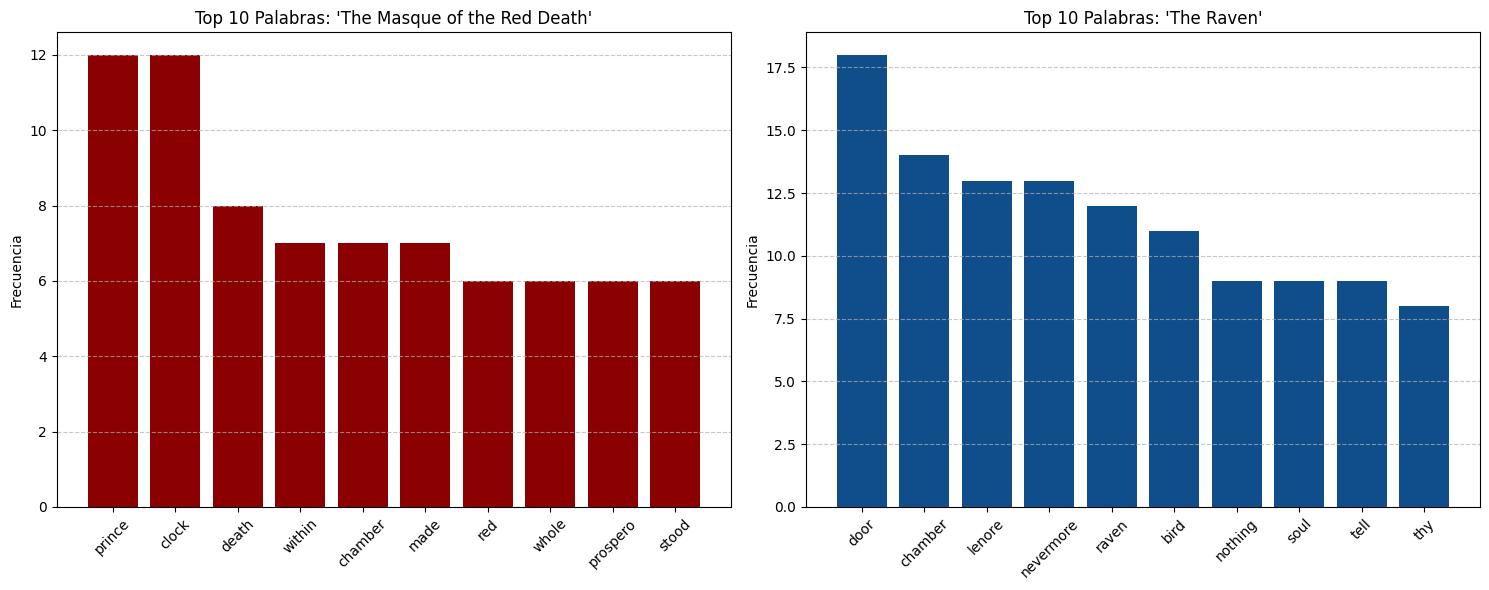

In [33]:
# Histograma
top_10_masque = freq_masque.most_common(10)
top_10_raven = freq_raven.most_common(10)

# Unimos los términos para hacer la comparativa en el gráfico
words_m, counts_m = zip(*top_10_masque)
words_r, counts_r = zip(*top_10_raven)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico para The Masque of the Red Death
axes[0].bar(words_m, counts_m, color='#8B0000') # Rojo obscuro
axes[0].set_title("Top 10 Palabras: 'The Masque of the Red Death'")
axes[0].set_ylabel("Frecuencia")
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico para The Raven
axes[1].bar(words_r, counts_r, color='#104E8B') # Azul obscuro
axes[1].set_title("Top 10 Palabras: 'The Raven'")
axes[1].set_ylabel("Frecuencia")
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('histogramas_frecuencia.png', dpi=300)
plt.show()

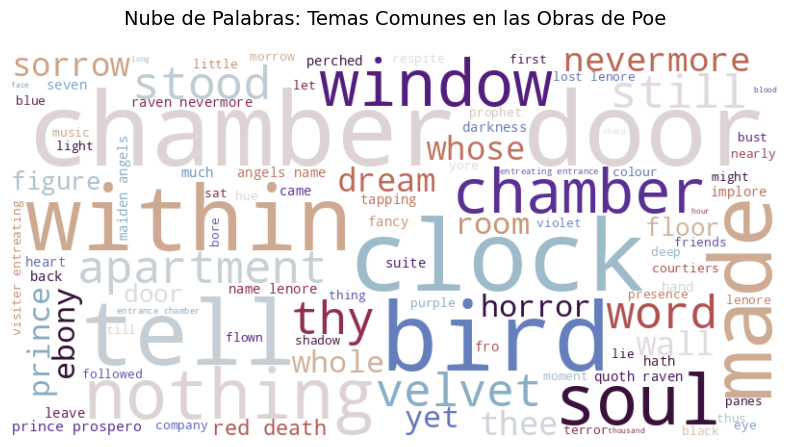

In [34]:
# Nube de palabras
# Combinamos ambos textos limpios para ver la esencia general de Poe en esta sesión
todo_poe = " ".join(clean_words_masque + clean_words_raven)

# Configurar y generar la nube de palabras
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='twilight_shifted', # Paleta de colores oscuros/góticos
    max_words=100
).generate(todo_poe)

# Desplegar el gráfico
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Quita los ejes numéricos
plt.title("Nube de Palabras: Temas Comunes en las Obras de Poe", fontsize=14, pad=20)
plt.savefig('wordcloud_poe.png', dpi=300) # Se guarda en tu Colab
plt.show()